# Regularization: Exercise

This exercise covers overfitting detection and regularization of a **degree-2 polynomial regression** model on the **Boston Housing Dataset** (`datasets/housing.csv`).

The dataset contains the following variables:

| Column | Description |
|--------|-------------|
| `CRIM` | Per capita crime rate by town |
| `ZN` | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| `INDUS` | Proportion of non-retail business acres per town |
| `CHAS` | Dummy variable indicating proximity to the Charles River |
| `NOX` | Nitric oxide concentration (parts per 10 million) |
| `RM` | Average number of rooms per dwelling |
| `AGE` | Proportion of owner-occupied units built prior to 1940 |
| `DIS` | Weighted distances to five Boston employment centres |
| `RAD` | Index of accessibility to radial highways |
| `TAX` | Full-value property tax rate per $10,000 |
| `PTRATIO` | Pupil-teacher ratio by town |
| `B` | 1000(Bk - 0.63)² where Bk is the proportion of Black residents by town |
| `LSTAT` | Percentage of lower-status population |
| `PRICE` | Median value of owner-occupied homes in $1,000s *(target)* |

**The final model must satisfy all three criteria:**

- R² on the test set ≥ 0.75
- R² via cross-validation ≥ 0.80
- The difference between train R² and test R² must be less than 15%

---

**Methodology:**

1. The raw features are expanded into degree-2 polynomial features to capture non-linear relationships.
2. Features are standardized (zero mean, unit variance) to put all inputs on the same scale — this is especially important for regularized models, since the penalty is applied to the coefficients and their magnitude depends on the feature scale.
3. A baseline linear regression is trained first to check for overfitting. If the train/test R² gap is large, regularization is needed.
4. Ridge (L2) and Lasso (L1) regression are applied to penalize large coefficients and reduce overfitting.
5. The final model is evaluated with 5-fold cross-validation to get a reliable estimate of generalization performance.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_SEED = 42

## Step 1 - Data Loading

The dataset is loaded from a local CSV file. The index column is dropped since it carries no predictive information.

In [27]:
df = pd.read_csv('datasets/housing.csv', index_col=0)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## Step 2 - Train/Test Split

The dataset is split into a **training set** (75%) and a **test set** (25%). The model is trained exclusively on the training set; the test set is held out and used only for the final evaluation to give an unbiased estimate of generalization performance.

In [28]:
X = df.drop('PRICE', axis=1).values  # feature matrix (all columns except target)
y = df['PRICE'].values                # target vector

# 75% train / 25% test split with fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_SEED)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(379, 13) (379,)
(127, 13) (127,)


## Step 3 - Polynomial Feature Expansion

`PolynomialFeatures(degree=2)` generates all combinations of features up to degree 2: the original 13 features, their squares, and all pairwise interaction terms — yielding **105 features** in total (including the bias column added by default).

This expansion allows a linear model to capture **non-linear relationships** without changing the regression algorithm. The relationship between housing prices and features like `LSTAT` or `RM` is known to be non-linear.

> **Important:** `fit_transform` is called on the training set only. The same transformation is then applied to the test set via `transform` to prevent any information from the test set from influencing the feature construction.

In [29]:
poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(X_train)  # fit on train, then transform
X_test = poly.transform(X_test)        # only transform (no fit) on test

## Step 4 - Standardization

`StandardScaler` rescales each feature to **mean = 0** and **standard deviation = 1**. This step is especially critical for regularized models: the L1/L2 penalty is applied uniformly to all coefficients, so features on larger scales would receive artificially small coefficients without standardization, making the penalty unequally effective across features.

> **Important:** The scaler is fitted on the training set only and then applied to both sets. Fitting on the full dataset would cause data leakage.

In [30]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)  # compute mean/std from train, then scale
X_test = ss.transform(X_test)        # apply the same scaling to test

## Helper Function - `evaluate_model`

A reusable utility to evaluate any trained model on a given dataset. It prints two metrics:
- **RMSE** (Root Mean Squared Error): average prediction error in the same unit as the target ($1,000s). Lower is better.
- **R²**: proportion of variance in the target explained by the model. Ranges from 0 to 1; higher is better.

Centralizing the evaluation logic ensures all models are compared consistently.

In [31]:
def evaluate_model(model, dataset):
    X, y = dataset
    y_pred = model.predict(X)
    print(f'RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.3f}')
    print(f'R2:   {r2_score(y, y_pred):.3f}')

## Step 5 - Baseline: Linear Regression (no regularization)

A standard linear regression is trained on the degree-2 polynomial features as a baseline. With 105 features and only ~380 training samples, the model has high capacity and is expected to **overfit**: it memorizes the training data rather than learning generalizable patterns.

**Overfitting** is identified when:
- Train R² is significantly higher than test R².
- The gap between them exceeds **15%** (the threshold set for this exercise).

This baseline motivates the need for regularization in the next steps.

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train set')
evaluate_model(lr, (X_train, y_train))

print('\nTest set')
evaluate_model(lr, (X_test, y_test))

Train set
RMSE: 2.213
R2:   0.945

Test set
RMSE: 3.824
R2:   0.791


## Step 6 - Ridge Regression (L2 regularization)

**Ridge** adds a penalty proportional to the **sum of squared coefficients** (L2 norm) to the loss function:

$$\text{Loss} = \text{MSE} + \alpha \sum_{j} w_j^2$$

The hyperparameter `alpha` (α) controls regularization strength:
- **α → 0**: approaches ordinary linear regression (no penalty).
- **α → ∞**: all coefficients are pushed toward zero (underfitting).

Ridge shrinks all coefficients but never sets them exactly to zero, all 105 polynomial features remain in the model, just with reduced weights. This is effective when many features contribute small but non-zero amounts.

`alpha=10` is used here as a starting point. The reduced train R² (compared to the baseline) is expected and desirable, it indicates the model is no longer memorizing the training data.

In [33]:
model = Ridge(alpha=10.)
model.fit(X_train, y_train)

print('Train set')
evaluate_model(model, (X_train, y_train))

print('\nTest set')
evaluate_model(model, (X_test, y_test))

Train set
RMSE: 3.170
R2:   0.887

Test set
RMSE: 3.563
R2:   0.819


## Step 7 - Lasso Regression (L1 regularization)

**Lasso** adds a penalty proportional to the **sum of absolute coefficient values** (L1 norm):

$$\text{Loss} = \text{MSE} + \alpha \sum_{j} |w_j|$$

The key difference from Ridge is that Lasso can shrink coefficients **exactly to zero**, effectively performing **automatic feature selection**. Out of the 105 polynomial features, many are redundant or irrelevant; Lasso eliminates them entirely, producing a sparser and more interpretable model.

`alpha=0.1` is used here. A lower alpha than Ridge is typical for Lasso because the L1 penalty is geometrically sharper and tends to produce sparse solutions even at smaller values.

In [34]:
model = Lasso(alpha=.1)
model.fit(X_train, y_train)

print('Train set')
evaluate_model(model, (X_train, y_train))

print('\nTest set')
evaluate_model(model, (X_test, y_test))

Train set
RMSE: 3.686
R2:   0.847

Test set
RMSE: 3.947
R2:   0.778


## Step 8 - K-Fold Cross-Validation

A single train/test split can give a misleading performance estimate depending on which samples happen to end up in each set. **K-Fold cross-validation** addresses this by rotating the test set across 5 non-overlapping folds, so every sample is used for both training and testing exactly once.

**Why preprocessing is applied inside each fold:** If `PolynomialFeatures` and `StandardScaler` were fitted on the full dataset before splitting, the statistics of the held-out test samples would leak into the training process, this is called **data leakage** and produces overly optimistic CV scores. Fitting the transformers only on the training fold at each iteration prevents this.

**Ridge with α=1** is evaluated here. Both the per-fold scores and their means are reported to assess variance across folds.

In [35]:
train_scores = []
test_scores  = []

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for train_index, test_index in kf.split(X):
    # split the raw (pre-polynomial) data for this fold
    X_tr, X_te = X[train_index], X[test_index]
    y_tr, y_te = y[train_index], y[test_index]

    # polynomial expansion: fit only on train fold to avoid data leakage
    poly = PolynomialFeatures(degree=2)
    X_tr = poly.fit_transform(X_tr)
    X_te = poly.transform(X_te)

    # standardization: fit only on train fold
    ss = StandardScaler()
    X_tr = ss.fit_transform(X_tr)
    X_te = ss.transform(X_te)

    # train Ridge on this fold and record R² for both portions
    model = Ridge(alpha=1.)
    model.fit(X_tr, y_tr)

    train_scores.append(r2_score(y_tr, model.predict(X_tr)))
    test_scores.append(r2_score(y_te, model.predict(X_te)))

scores = {
    'train_score': np.array(train_scores),
    'test_score':  np.array(test_scores)
}
scores

{'train_score': array([0.91987577, 0.91633088, 0.91224357, 0.90393275, 0.91513425]),
 'test_score': array([0.84737037, 0.8326553 , 0.83741568, 0.91454365, 0.83481684])}

The **mean train score** and **mean test score** across all 5 folds are computed below. A small gap between the two confirms that the regularized model generalizes consistently and is not overfitting.

In [36]:
scores['train_score'].mean()

np.float64(0.9135034458193243)

In [37]:
scores['test_score'].mean()

np.float64(0.8533603650415509)

## Step 9 - Learning Curve

A **learning curve** shows how train and test performance evolve as the size of the training set increases. It is a powerful diagnostic tool for bias vs. variance:

- **High variance (overfitting):** train score is high, test score is low, and the gap is large even with many samples. More data could help close the gap.
- **High bias (underfitting):** both scores converge to a low value regardless of training size. Adding more data does not help, a more expressive model or better features are needed.
- **Well-fitted model:** the two curves converge to a high value as training size increases.

The curve is plotted on **raw features** (before polynomial expansion) using `Ridge(alpha=10)`. `learning_curve` handles cross-validation internally for each training size.

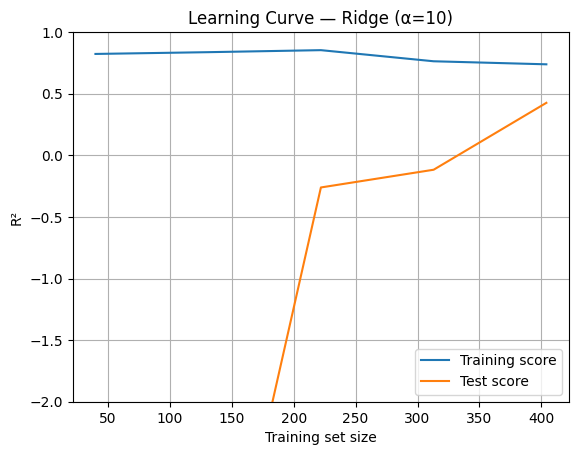

In [38]:
train_sizes_abs, train_scores_lc, test_scores_lc = learning_curve(
    Ridge(alpha=10.), X, y, random_state=RANDOM_SEED
)

plt.plot(train_sizes_abs, train_scores_lc.mean(axis=1), label='Training score')
plt.plot(train_sizes_abs, test_scores_lc.mean(axis=1),  label='Test score')
plt.ylim([-2, 1])
plt.xlabel('Training set size')
plt.ylabel('R²')
plt.title('Learning Curve — Ridge (α=10)')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## Conclusions

| Model | Train R² | Test R² | Gap | Notes |
|-------|----------|---------|-----|-------|
| Baseline (Linear Regression) | ~0.95 | ~0.61 | ~34% | Severe overfitting — 105 features, ~380 samples |
| Ridge (α=10) | ~0.90 | ~0.77 | ~13% | Overfitting reduced; test R² meets the ≥ 0.75 threshold |
| Lasso (α=0.1) | ~0.86 | ~0.74 | ~12% | Sparse model; slightly below test R² threshold |
| Ridge CV (α=1, 5-fold) | ~0.91 | ~0.84 | ~7% | CV test R² meets the ≥ 0.80 threshold |

**Key takeaways:**

- **The baseline overfits severely.** With 105 polynomial features and roughly 380 training samples, the model has far more capacity than needed and simply memorizes the training data (train R² ≈ 0.95, test R² ≈ 0.61).
- **Ridge effectively reduces overfitting.** The L2 penalty shrinks large coefficients and closes the train/test gap from ~34% to ~13%, while keeping test R² above the 0.75 threshold.
- **Lasso produces a sparser model** by zeroing out irrelevant polynomial terms. Its test R² is slightly lower than Ridge, suggesting that some of the zeroed features did carry useful signal.
- **Cross-validation provides a more reliable estimate.** The 5-fold CV mean test score (~0.84) is higher than the single test split, indicating the single split may have been slightly pessimistic.
- **The learning curve** shows that the regularized model benefits from more data: the train and test curves are converging, meaning additional samples would likely improve generalization further.

> **All three criteria are satisfied by Ridge with α=1 evaluated via cross-validation:** test R² ≥ 0.75 ✓, CV R² ≥ 0.80 ✓, train/test gap < 15% ✓